# 03. EDA Databricks con SparkSQL

Lee datasets trusted Databrickses y genera tablas refined en Parquet/CSV.


In [0]:
%run ./00_configuracion


# 00_configuracion_databricks

Configuración común del proyecto TCGA/RNA-Seq en Databricks.

Este archivo conserva la estructura funcional del `00_configuracion` probado en Databricks y agrega
las funciones reutilizables que necesitan los notebooks 02 a 07.

Configuración cargada correctamente.
Ruta base: /Volumes/workspace/default/tcga_cancer_ml
Número de clases oficiales: 18


Estructura creada correctamente:
/Volumes/workspace/default/tcga_cancer_ml
/Volumes/workspace/default/tcga_cancer_ml/raw
/Volumes/workspace/default/tcga_cancer_ml/trusted
/Volumes/workspace/default/tcga_cancer_ml/refined
/Volumes/workspace/default/tcga_cancer_ml/models
/Volumes/workspace/default/tcga_cancer_ml/raw/rnaseq
/Volumes/workspace/default/tcga_cancer_ml/raw/metadata
/Volumes/workspace/default/tcga_cancer_ml/trusted/rnaseq_long
/Volumes/workspace/default/tcga_cancer_ml/trusted/rnaseq_matrix
/Volumes/workspace/default/tcga_cancer_ml/trusted/samples_18_clases
/Volumes/workspace/default/tcga_cancer_ml/trusted/gene_dictionary
/Volumes/workspace/default/tcga_cancer_ml/refined/eda_outputs
/Volumes/workspace/default/tcga_cancer_ml/refined/model_metrics
/Volumes/workspace/default/tcga_cancer_ml/refined/predictions
/Volumes/workspace/default/tcga_cancer_ml/refined/visualizations
/Volumes/workspace/default/tcga_cancer_ml/refined/tables
/Volumes/workspace/default/tcga_cancer_ml/refined/ex

RAW_METADATA_FILE: /Volumes/workspace/default/tcga_cancer_ml/raw/metadata/metadatos_tcga_oficial_18_clases.csv
RAW_RNASEQ_PATH: /Volumes/workspace/default/tcga_cancer_ml/raw/rnaseq


muestras_unicas_long,filas_samples,muestras_unicas_samples,pacientes_unicos_long,genes_unicos_long
8335,8335,8335,8283,19944


00_configuracion listo para notebooks 02 a 07.


In [0]:
from pyspark.sql import functions as F
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

# Helper functions and paths (since %run failed)
def read_trusted(path):
    return spark.read.format("delta").load(str(path))

def mostrar(obj, n=10):
    if hasattr(obj, "limit") and hasattr(obj, "toPandas"):
        return display(obj.limit(n))
    return display(obj)

TRUSTED_LONG_PATH = "/Volumes/workspace/default/tcga_cancer_ml/trusted/rnaseq_long"
TRUSTED_SAMPLES_PATH = "/Volumes/workspace/default/tcga_cancer_ml/trusted/samples_18_clases"

df_trusted = read_trusted(TRUSTED_LONG_PATH)
df_samples = read_trusted(TRUSTED_SAMPLES_PATH)

df_trusted.createOrReplaceTempView("trusted_long")
df_samples.createOrReplaceTempView("trusted_samples")

print("Registros long:", df_trusted.count())
print("Muestras:", df_samples.count())
mostrar(df_trusted, 5)


Registros long: 169058178
Muestras: 8469


file_id,file_name,case_id,case_submitter_id,sample_id,sample_submitter_id,patient_id,sample_type,project_id,cancer_type,cancer_name,gene_id_base,gene_name,gene_type,tpm_unstranded,log2_tpm,source_file
95cff59f-cec7-490d-9519-83b39c202cb2,c29f985d-859c-4eaf-8593-276ac8d6af69.rna_seq.augmented_star_gene_counts.tsv,c7353d6a-82a2-4a0d-8cd4-8c8957943edb,TCGA-BA-4078,2027ede3-13f5-40f6-bef6-16704981d676,TCGA-BA-4078-01A,TCGA-BA-4078,Primary Tumor,TCGA-HNSC,HNSC,Head and neck squamous cell carcinoma,ENSG00000000003,TSPAN6,protein_coding,44.4657,5.506706659954545,dbfs:/Volumes/workspace/default/tcga_cancer_ml/raw/rnaseq/95cff59f-cec7-490d-9519-83b39c202cb2/c29f985d-859c-4eaf-8593-276ac8d6af69.rna_seq.augmented_star_gene_counts.tsv
95cff59f-cec7-490d-9519-83b39c202cb2,c29f985d-859c-4eaf-8593-276ac8d6af69.rna_seq.augmented_star_gene_counts.tsv,c7353d6a-82a2-4a0d-8cd4-8c8957943edb,TCGA-BA-4078,2027ede3-13f5-40f6-bef6-16704981d676,TCGA-BA-4078-01A,TCGA-BA-4078,Primary Tumor,TCGA-HNSC,HNSC,Head and neck squamous cell carcinoma,ENSG00000000005,TNMD,protein_coding,0.0,0.0,dbfs:/Volumes/workspace/default/tcga_cancer_ml/raw/rnaseq/95cff59f-cec7-490d-9519-83b39c202cb2/c29f985d-859c-4eaf-8593-276ac8d6af69.rna_seq.augmented_star_gene_counts.tsv
95cff59f-cec7-490d-9519-83b39c202cb2,c29f985d-859c-4eaf-8593-276ac8d6af69.rna_seq.augmented_star_gene_counts.tsv,c7353d6a-82a2-4a0d-8cd4-8c8957943edb,TCGA-BA-4078,2027ede3-13f5-40f6-bef6-16704981d676,TCGA-BA-4078-01A,TCGA-BA-4078,Primary Tumor,TCGA-HNSC,HNSC,Head and neck squamous cell carcinoma,ENSG00000000419,DPM1,protein_coding,80.36,6.346247774082776,dbfs:/Volumes/workspace/default/tcga_cancer_ml/raw/rnaseq/95cff59f-cec7-490d-9519-83b39c202cb2/c29f985d-859c-4eaf-8593-276ac8d6af69.rna_seq.augmented_star_gene_counts.tsv
95cff59f-cec7-490d-9519-83b39c202cb2,c29f985d-859c-4eaf-8593-276ac8d6af69.rna_seq.augmented_star_gene_counts.tsv,c7353d6a-82a2-4a0d-8cd4-8c8957943edb,TCGA-BA-4078,2027ede3-13f5-40f6-bef6-16704981d676,TCGA-BA-4078-01A,TCGA-BA-4078,Primary Tumor,TCGA-HNSC,HNSC,Head and neck squamous cell carcinoma,ENSG00000000457,SCYL3,protein_coding,12.763,3.7827230717136833,dbfs:/Volumes/workspace/default/tcga_cancer_ml/raw/rnaseq/95cff59f-cec7-490d-9519-83b39c202cb2/c29f985d-859c-4eaf-8593-276ac8d6af69.rna_seq.augmented_star_gene_counts.tsv
95cff59f-cec7-490d-9519-83b39c202cb2,c29f985d-859c-4eaf-8593-276ac8d6af69.rna_seq.augmented_star_gene_counts.tsv,c7353d6a-82a2-4a0d-8cd4-8c8957943edb,TCGA-BA-4078,2027ede3-13f5-40f6-bef6-16704981d676,TCGA-BA-4078-01A,TCGA-BA-4078,Primary Tumor,TCGA-HNSC,HNSC,Head and neck squamous cell carcinoma,ENSG00000000460,C1orf112,protein_coding,14.7693,3.9790467151335567,dbfs:/Volumes/workspace/default/tcga_cancer_ml/raw/rnaseq/95cff59f-cec7-490d-9519-83b39c202cb2/c29f985d-859c-4eaf-8593-276ac8d6af69.rna_seq.augmented_star_gene_counts.tsv


In [0]:
eda_resumen_general = spark.sql("""
    SELECT
        (SELECT COUNT(*) FROM trusted_long) AS n_registros_long,
        (SELECT COUNT(DISTINCT sample_id) FROM trusted_long) AS n_muestras_long,
        (SELECT COUNT(*) FROM trusted_samples) AS n_filas_samples,
        (SELECT COUNT(DISTINCT sample_id) FROM trusted_samples) AS n_muestras_samples,
        (SELECT COUNT(DISTINCT patient_id) FROM trusted_long) AS n_pacientes,
        (SELECT COUNT(DISTINCT cancer_type) FROM trusted_long) AS n_clases,
        (SELECT COUNT(DISTINCT gene_id_base) FROM trusted_long) AS n_genes_long
""")
mostrar(eda_resumen_general)


n_registros_long,n_muestras_long,n_filas_samples,n_muestras_samples,n_pacientes,n_clases,n_genes_long
169058178,8335,8469,8335,8283,18,19944


cancer_type,cancer_name,n_muestras,n_pacientes
BRCA,Breast invasive carcinoma,1106,1095
UCEC,Uterine corpus endometrial carcinoma,549,545
KIRC,Kidney renal clear cell carcinoma,537,533
LUAD,Lung adenocarcinoma,529,517
HNSC,Head and neck squamous cell carcinoma,520,520
LGG,Brain lower grade glioma,516,516
THCA,Thyroid carcinoma,505,505
LUSC,Lung squamous cell carcinoma,501,501
PRAD,Prostate adenocarcinoma,501,497
COAD,Colon adenocarcinoma,471,458


Tabla Delta guardada: `workspace`.`default`.`refined_eda_conteo_clases`
Copia física en Volume: /Volumes/workspace/default/tcga_cancer_ml/refined/tables/refined_eda_conteo_clases


cancer_type,n_muestras,porcentaje,razon_desbalance_global
BRCA,1106,13.27,10.74
UCEC,549,6.59,10.74
KIRC,537,6.44,10.74
LUAD,529,6.35,10.74
HNSC,520,6.24,10.74
LGG,516,6.19,10.74
THCA,505,6.06,10.74
PRAD,501,6.01,10.74
LUSC,501,6.01,10.74
COAD,471,5.65,10.74


Tabla Delta guardada: `workspace`.`default`.`refined_eda_desbalance_clases`
Copia física en Volume: /Volumes/workspace/default/tcga_cancer_ml/refined/tables/refined_eda_desbalance_clases
Figura guardada: /Volumes/workspace/default/tcga_cancer_ml/refined/visualizations/distribucion_clases.png


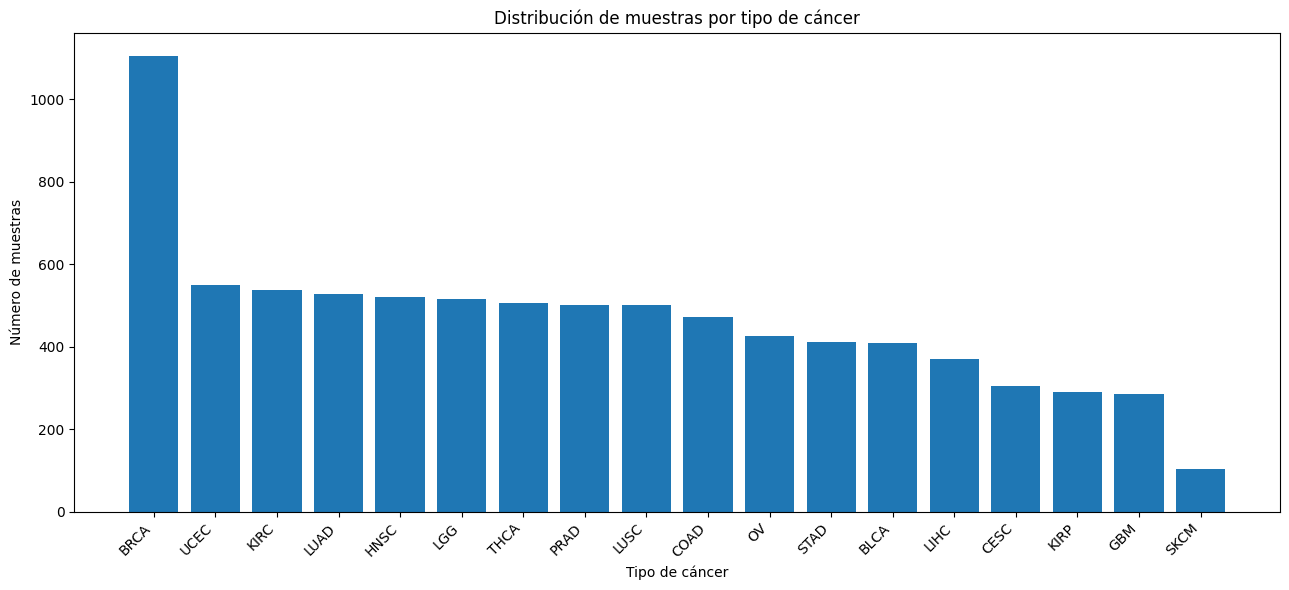

In [0]:
eda_conteo_clases = spark.sql("""
    SELECT cancer_type, cancer_name,
           COUNT(DISTINCT sample_id) AS n_muestras,
           COUNT(DISTINCT patient_id) AS n_pacientes
    FROM trusted_long
    GROUP BY cancer_type, cancer_name
    ORDER BY n_muestras DESC
""")
mostrar(eda_conteo_clases, 30)
save_spark_table(eda_conteo_clases, "refined_eda_conteo_clases")

eda_desbalance_clases = spark.sql("""
    WITH conteo AS (
        SELECT cancer_type, COUNT(DISTINCT sample_id) AS n_muestras
        FROM trusted_long GROUP BY cancer_type
    ),
    total AS (SELECT SUM(n_muestras) AS total_muestras FROM conteo),
    extremos AS (SELECT MAX(n_muestras) AS max_muestras, MIN(n_muestras) AS min_muestras FROM conteo)
    SELECT c.cancer_type, c.n_muestras,
           ROUND(100 * c.n_muestras / t.total_muestras, 2) AS porcentaje,
           ROUND(e.max_muestras / e.min_muestras, 2) AS razon_desbalance_global
    FROM conteo c CROSS JOIN total t CROSS JOIN extremos e
    ORDER BY c.n_muestras DESC
""")
mostrar(eda_desbalance_clases, 30)
save_spark_table(eda_desbalance_clases, "refined_eda_desbalance_clases")

pdf = eda_conteo_clases.toPandas()
plt.figure(figsize=(13,6))
plt.bar(pdf["cancer_type"], pdf["n_muestras"])
plt.title("Distribución de muestras por tipo de cáncer")
plt.xlabel("Tipo de cáncer")
plt.ylabel("Número de muestras")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
guardar_figura("distribucion_clases.png")
plt.show()


In [0]:
eda_calidad_datos = spark.sql("""
    SELECT cancer_type,
           COUNT(*) AS n_registros,
           SUM(CASE WHEN log2_tpm IS NULL THEN 1 ELSE 0 END) AS n_log2_tpm_null,
           SUM(CASE WHEN tpm_unstranded IS NULL THEN 1 ELSE 0 END) AS n_tpm_null,
           SUM(CASE WHEN tpm_unstranded = 0 THEN 1 ELSE 0 END) AS n_tpm_cero,
           ROUND(100 * SUM(CASE WHEN tpm_unstranded = 0 THEN 1 ELSE 0 END) / COUNT(*), 2) AS pct_tpm_cero
    FROM trusted_long
    GROUP BY cancer_type
    ORDER BY pct_tpm_cero DESC
""")
mostrar(eda_calidad_datos, 30)
save_spark_table(eda_calidad_datos, "refined_eda_calidad_datos")

eda_sample_type = spark.sql("""
    SELECT sample_type, COUNT(DISTINCT sample_id) AS n_muestras, COUNT(DISTINCT patient_id) AS n_pacientes
    FROM trusted_long
    GROUP BY sample_type
    ORDER BY n_muestras DESC
""")
mostrar(eda_sample_type)
save_spark_table(eda_sample_type, "refined_eda_tipos_muestra")


cancer_type,n_registros,n_log2_tpm_null,n_tpm_null,n_tpm_cero,pct_tpm_cero
LIHC,7405902,0,0,1259617,17.01
COAD,9601722,0,0,1531181,15.95
SKCM,2056086,0,0,314600,15.3
KIRP,5788980,0,0,850598,14.69
BLCA,8224344,0,0,1201066,14.6
THCA,10080810,0,0,1449224,14.38
UCEC,11038986,0,0,1583616,14.35
CESC,6068448,0,0,868308,14.31
HNSC,10380240,0,0,1438369,13.86
BRCA,22177782,0,0,3013154,13.59


Tabla Delta guardada: `workspace`.`default`.`refined_eda_calidad_datos`
Copia física en Volume: /Volumes/workspace/default/tcga_cancer_ml/refined/tables/refined_eda_calidad_datos


sample_type,n_muestras,n_pacientes
Primary Tumor,8335,8283


Tabla Delta guardada: `workspace`.`default`.`refined_eda_tipos_muestra`
Copia física en Volume: /Volumes/workspace/default/tcga_cancer_ml/refined/tables/refined_eda_tipos_muestra


PosixPath('/Volumes/workspace/default/tcga_cancer_ml/refined/tables/refined_eda_tipos_muestra')

cancer_type,n_registros,media_log2_tpm,sd_log2_tpm,min_log2_tpm,q1_log2_tpm,mediana_log2_tpm,q3_log2_tpm,max_log2_tpm
BLCA,8224344,2.7135,2.4391,0.0,0.2167,2.4953,4.5337,16.9432
BRCA,22177782,2.9241,2.475,0.0,0.3149,2.8829,4.8145,18.0636
CESC,6068448,2.7861,2.4765,0.0,0.2167,2.6236,4.6615,17.324
COAD,9601722,2.7731,2.4612,0.0,0.2327,2.5995,4.6339,16.784
GBM,7425864,2.7851,2.2825,0.0,0.458,2.7407,4.4715,16.0216
HNSC,10380240,2.7207,2.4526,0.0,0.2192,2.4919,4.55,16.5445
KIRC,10799442,2.7792,2.3895,0.0,0.2812,2.7008,4.5607,16.9897
KIRP,5788980,2.6392,2.372,0.0,0.2033,2.4256,4.4061,17.4248
LGG,10300392,2.9575,2.4253,0.0,0.3936,2.9858,4.8042,17.1992
LIHC,7405902,2.3125,2.3247,0.0,0.1021,1.8084,3.8946,17.4027


Tabla Delta guardada: `workspace`.`default`.`refined_eda_expresion_global`
Copia física en Volume: /Volumes/workspace/default/tcga_cancer_ml/refined/tables/refined_eda_expresion_global
Figura guardada: /Volumes/workspace/default/tcga_cancer_ml/refined/visualizations/expresion_promedio_por_clase.png


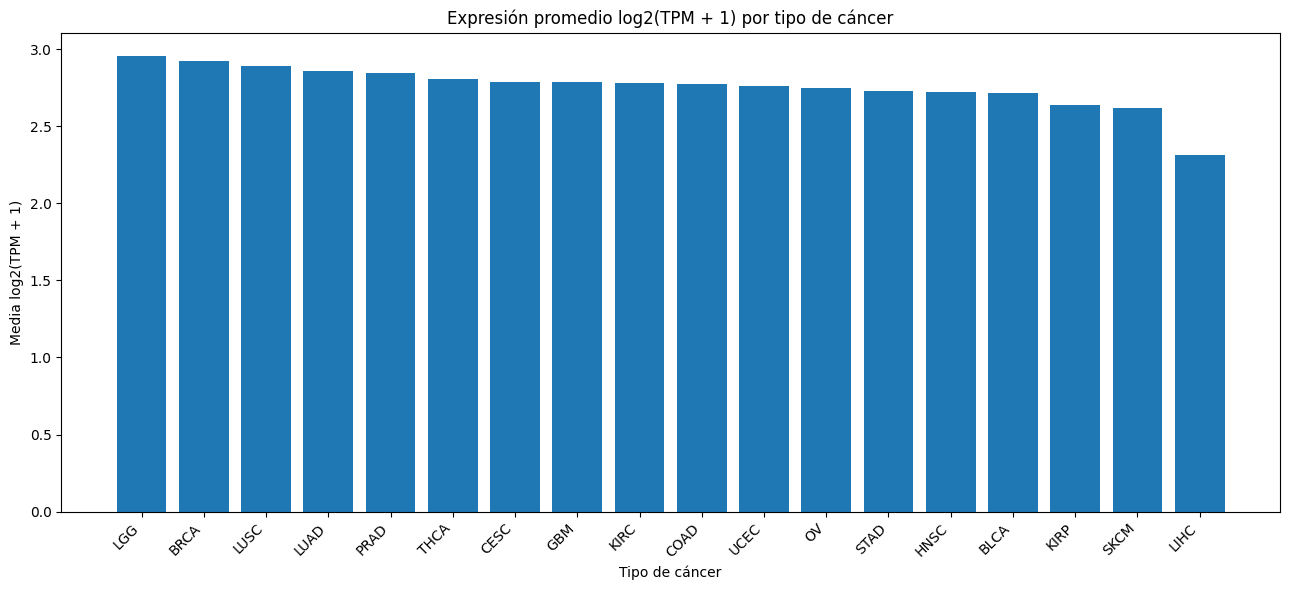

In [0]:
eda_expresion_global = spark.sql("""
    SELECT cancer_type,
           COUNT(*) AS n_registros,
           ROUND(AVG(log2_tpm), 4) AS media_log2_tpm,
           ROUND(STDDEV(log2_tpm), 4) AS sd_log2_tpm,
           ROUND(MIN(log2_tpm), 4) AS min_log2_tpm,
           ROUND(percentile_approx(log2_tpm, 0.25), 4) AS q1_log2_tpm,
           ROUND(percentile_approx(log2_tpm, 0.50), 4) AS mediana_log2_tpm,
           ROUND(percentile_approx(log2_tpm, 0.75), 4) AS q3_log2_tpm,
           ROUND(MAX(log2_tpm), 4) AS max_log2_tpm
    FROM trusted_long
    GROUP BY cancer_type
    ORDER BY cancer_type
""")
mostrar(eda_expresion_global, 30)
save_spark_table(eda_expresion_global, "refined_eda_expresion_global")

pdf_expr = eda_expresion_global.toPandas().sort_values("media_log2_tpm", ascending=False)
plt.figure(figsize=(13,6))
plt.bar(pdf_expr["cancer_type"], pdf_expr["media_log2_tpm"])
plt.title("Expresión promedio log2(TPM + 1) por tipo de cáncer")
plt.xlabel("Tipo de cáncer")
plt.ylabel("Media log2(TPM + 1)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
guardar_figura("expresion_promedio_por_clase.png")
plt.show()


## Distribución de la expresión: cruda vs. log2

Se compara la distribución del TPM crudo frente a `log2(TPM + 1)` para justificar la transformación logarítmica usada en el modelado. El TPM crudo presenta una fuerte asimetría a la derecha (pocos genes con expresión muy alta), mientras que la escala logarítmica estabiliza la varianza y aproxima una forma simétrica. Se cuantifica con asimetría y curtosis sobre toda la tabla larga, y se acompaña de histogramas y un boxplot de `log2(TPM + 1)` por tipo de cáncer.


media_tpm,sd_tpm,asimetria_tpm,curtosis_tpm,media_log2,sd_log2,asimetria_log2,curtosis_log2,pct_tpm_cero
44.4997,572.6893,67.0743,7242.1986,2.7872,2.4208,0.5564,-0.3214,13.61


Tabla Delta guardada: `workspace`.`default`.`refined_eda_distribucion_expresion`
Copia física en Volume: /Volumes/workspace/default/tcga_cancer_ml/refined/tables/refined_eda_distribucion_expresion
Muestra para histogramas: 300000 registros
Figura guardada: /Volumes/workspace/default/tcga_cancer_ml/refined/visualizations/distribucion_expresion_cruda_vs_log.png


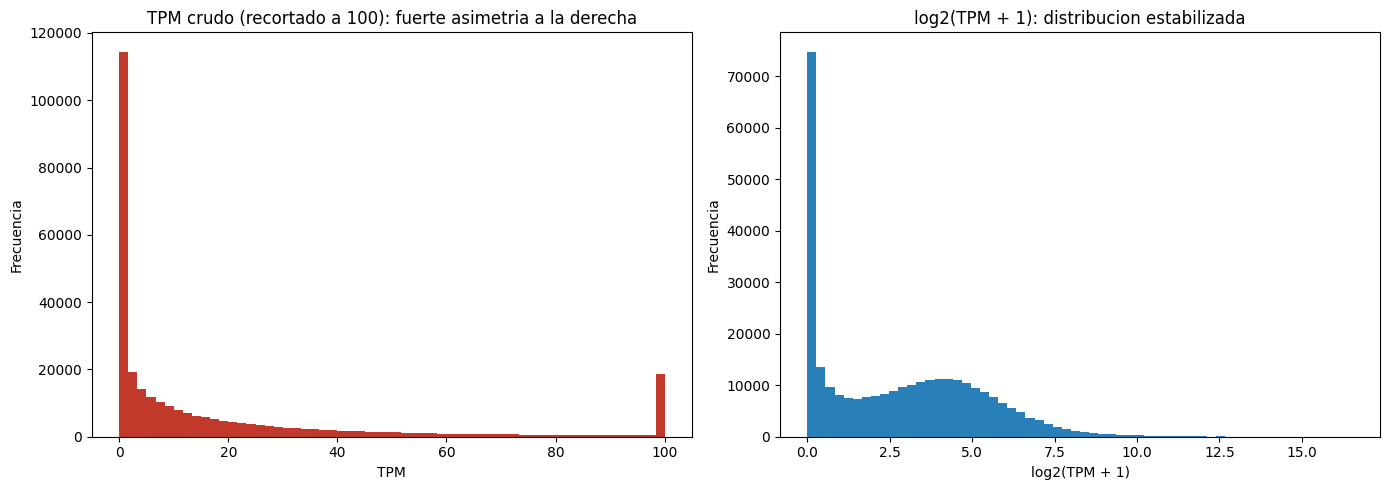

Figura guardada: /Volumes/workspace/default/tcga_cancer_ml/refined/visualizations/boxplot_log2_tpm_por_clase.png


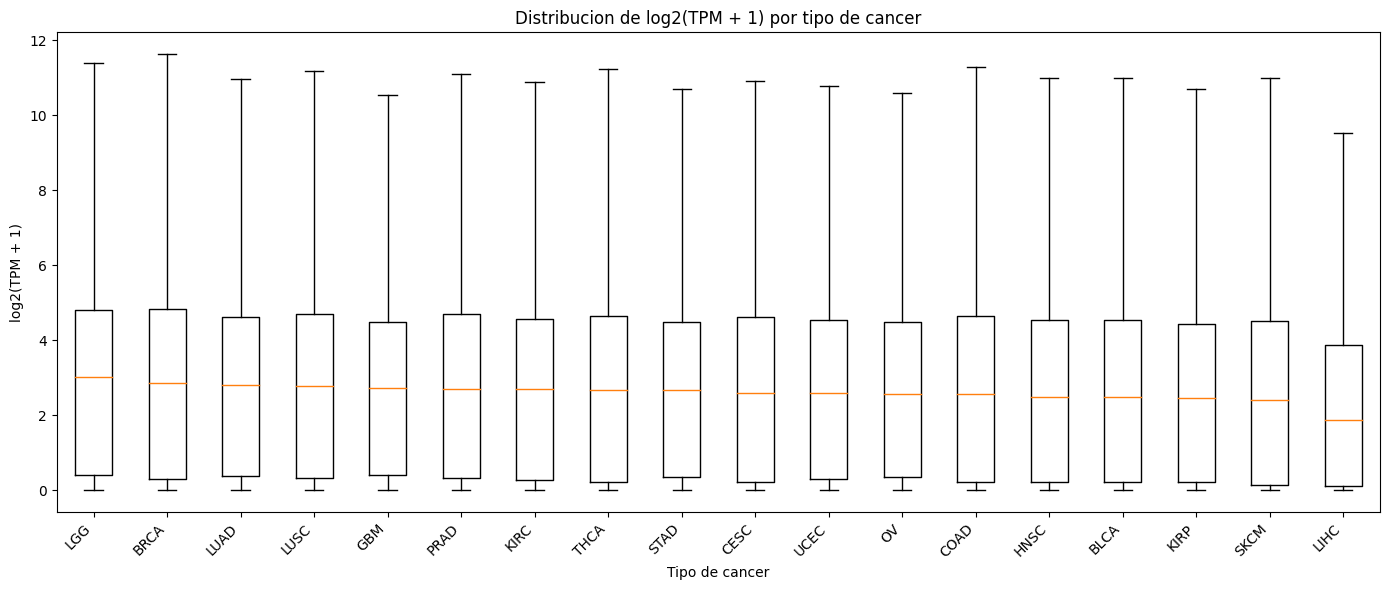

In [0]:
# === Distribución de expresión: cruda vs log2 (justifica la transformación logarítmica) ===
# Estadísticos de forma sobre toda la tabla larga
eda_distribucion_expresion = spark.sql("""
    SELECT
        ROUND(AVG(tpm_unstranded), 4)      AS media_tpm,
        ROUND(STDDEV(tpm_unstranded), 4)   AS sd_tpm,
        ROUND(skewness(tpm_unstranded), 4) AS asimetria_tpm,
        ROUND(kurtosis(tpm_unstranded), 4) AS curtosis_tpm,
        ROUND(AVG(log2_tpm), 4)            AS media_log2,
        ROUND(STDDEV(log2_tpm), 4)         AS sd_log2,
        ROUND(skewness(log2_tpm), 4)       AS asimetria_log2,
        ROUND(kurtosis(log2_tpm), 4)       AS curtosis_log2,
        ROUND(100 * AVG(CASE WHEN tpm_unstranded = 0 THEN 1 ELSE 0 END), 2) AS pct_tpm_cero
    FROM trusted_long
""")
mostrar(eda_distribucion_expresion)
save_spark_table(eda_distribucion_expresion, "refined_eda_distribucion_expresion")

# Muestra para los histogramas (la tabla larga es demasiado grande para traerla completa)
frac_hist = float(os.getenv("TCGA_FRAC_HIST_EDA", "0.01"))
pdf_hist = (spark.table("trusted_long")
            .select("cancer_type", "tpm_unstranded", "log2_tpm")
            .sample(withReplacement=False, fraction=frac_hist, seed=42)
            .toPandas())
if len(pdf_hist) > 300000:
    pdf_hist = pdf_hist.sample(300000, random_state=42)
print("Muestra para histogramas:", len(pdf_hist), "registros")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(pdf_hist["tpm_unstranded"].clip(upper=100), bins=60, color="#c0392b")
axes[0].set_title("TPM crudo (recortado a 100): fuerte asimetria a la derecha")
axes[0].set_xlabel("TPM"); axes[0].set_ylabel("Frecuencia")
axes[1].hist(pdf_hist["log2_tpm"], bins=60, color="#2980b9")
axes[1].set_title("log2(TPM + 1): distribucion estabilizada")
axes[1].set_xlabel("log2(TPM + 1)"); axes[1].set_ylabel("Frecuencia")
plt.tight_layout()
guardar_figura("distribucion_expresion_cruda_vs_log.png")
plt.show()

# Boxplot de log2(TPM + 1) por tipo de cancer
orden = (pdf_hist.groupby("cancer_type")["log2_tpm"].median()
         .sort_values(ascending=False).index.tolist())
datos_box = [pdf_hist.loc[pdf_hist["cancer_type"] == c, "log2_tpm"].values for c in orden]
plt.figure(figsize=(14, 6))
plt.boxplot(datos_box, labels=orden, showfliers=False)
plt.title("Distribucion de log2(TPM + 1) por tipo de cancer")
plt.xlabel("Tipo de cancer"); plt.ylabel("log2(TPM + 1)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
guardar_figura("boxplot_log2_tpm_por_clase.png")
plt.show()


gene_id_base,gene_name,media_global,sd_entre_clases,rango_entre_clases
ENSG00000186081,KRT5,4.1985,4.105,12.7183
ENSG00000205420,KRT6A,3.5464,4.0173,13.119
ENSG00000186847,KRT14,3.4381,3.7118,13.2007
ENSG00000131095,GFAP,1.5914,3.708,12.0203
ENSG00000171345,KRT19,7.4214,3.6706,10.8336
ENSG00000128422,KRT17,5.4101,3.5483,11.54
ENSG00000186832,KRT16,3.3211,3.4745,11.6363
ENSG00000106541,AGR2,4.6437,3.4251,9.3702
ENSG00000165215,CLDN3,5.7522,3.3917,9.9525
ENSG00000184292,TACSTD2,6.8283,3.3235,9.9644


Tabla Delta guardada: `workspace`.`default`.`refined_eda_genes_mas_variables`
Copia física en Volume: /Volumes/workspace/default/tcga_cancer_ml/refined/tables/refined_eda_genes_mas_variables
Tabla Delta guardada: `workspace`.`default`.`refined_eda_top_genes_por_clase`
Copia física en Volume: /Volumes/workspace/default/tcga_cancer_ml/refined/tables/refined_eda_top_genes_por_clase
Figura guardada: /Volumes/workspace/default/tcga_cancer_ml/refined/visualizations/top20_genes_variables.png


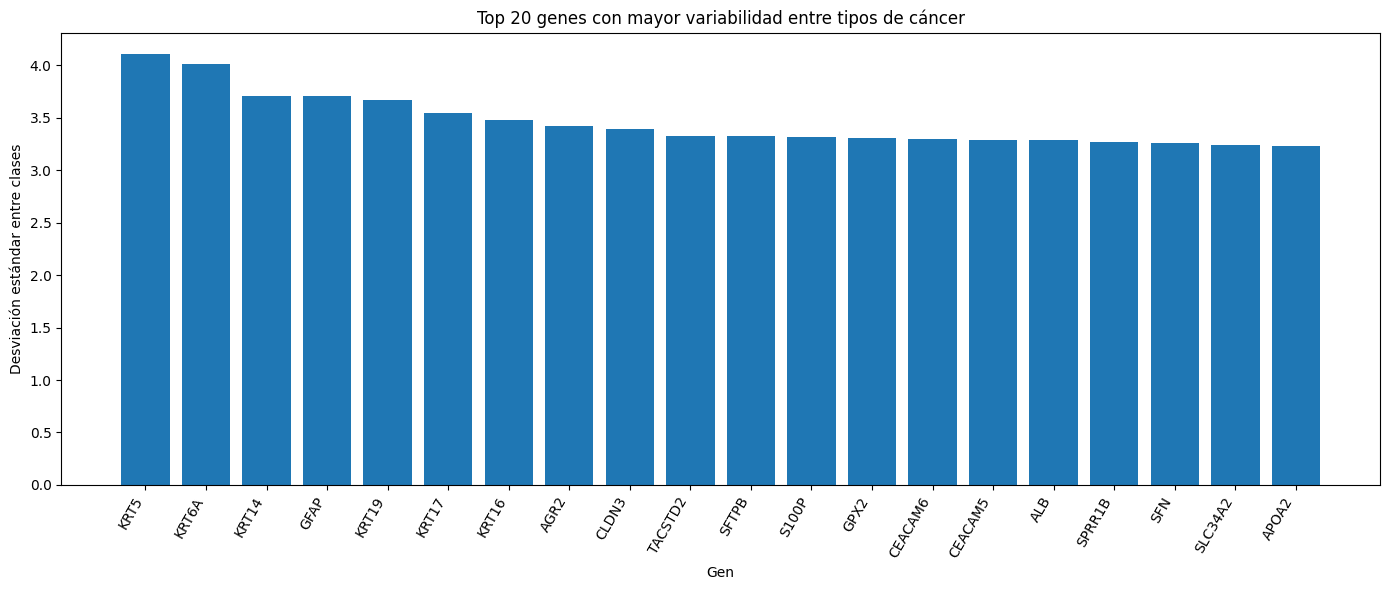

In [0]:
TOP_GENES_VARIABLES = int(os.getenv("TCGA_TOP_GENES_VARIABLES_EDA", "5000"))

eda_genes_mas_variables = spark.sql(f"""
    WITH media_por_clase AS (
        SELECT gene_id_base, gene_name, cancer_type, AVG(log2_tpm) AS media_clase
        FROM trusted_long
        GROUP BY gene_id_base, gene_name, cancer_type
    ),
    variabilidad AS (
        SELECT gene_id_base, gene_name,
               AVG(media_clase) AS media_global,
               STDDEV(media_clase) AS sd_entre_clases,
               MAX(media_clase) - MIN(media_clase) AS rango_entre_clases
        FROM media_por_clase
        GROUP BY gene_id_base, gene_name
    )
    SELECT gene_id_base, gene_name,
           ROUND(media_global, 4) AS media_global,
           ROUND(sd_entre_clases, 4) AS sd_entre_clases,
           ROUND(rango_entre_clases, 4) AS rango_entre_clases
    FROM variabilidad
    ORDER BY sd_entre_clases DESC
    LIMIT {TOP_GENES_VARIABLES}
""")
mostrar(eda_genes_mas_variables, 30)
save_spark_table(eda_genes_mas_variables, "refined_eda_genes_mas_variables")

eda_top_genes_por_clase = spark.sql("""
    WITH expresion_gen AS (
        SELECT cancer_type, gene_id_base, gene_name, AVG(log2_tpm) AS avg_log2_tpm
        FROM trusted_long
        GROUP BY cancer_type, gene_id_base, gene_name
    ),
    ranking AS (
        SELECT *, ROW_NUMBER() OVER (PARTITION BY cancer_type ORDER BY avg_log2_tpm DESC) AS rank_gen
        FROM expresion_gen
    )
    SELECT cancer_type, rank_gen, gene_id_base, gene_name, ROUND(avg_log2_tpm, 4) AS avg_log2_tpm
    FROM ranking
    WHERE rank_gen <= 10
    ORDER BY cancer_type, rank_gen
""")
save_spark_table(eda_top_genes_por_clase, "refined_eda_top_genes_por_clase")

pdf_genes = eda_genes_mas_variables.limit(20).toPandas()
plt.figure(figsize=(14,6))
plt.bar(pdf_genes["gene_name"], pdf_genes["sd_entre_clases"])
plt.title("Top 20 genes con mayor variabilidad entre tipos de cáncer")
plt.xlabel("Gen")
plt.ylabel("Desviación estándar entre clases")
plt.xticks(rotation=60, ha="right")
plt.tight_layout()
guardar_figura("top20_genes_variables.png")
plt.show()


## Control de efectos de lote (batch effects)

TCGA no expone aqui variables tecnicas explicitas (placa, centro o fecha de secuenciacion), pero el *barcode* `TCGA-TSS-...` codifica el **Tissue Source Site (TSS)**, el centro de origen de la muestra, que funciona como proxy de lote. Se evalua hasta que punto el TSS esta confundido con la variable objetivo `cancer_type`:

- **Diversidad dentro de la clase**: cuantos centros distintos aporta cada tipo de cancer y que peso tiene el centro dominante. Mucha diversidad y baja dominancia implica que el modelo no puede apoyarse en un atajo del tipo "un centro = un cancer".
- **Solapamiento entre clases**: cuantos TSS contribuyen a mas de un tipo de cancer. En TCGA el codigo TSS es especifico de enfermedad, por lo que queda anidado dentro de la clase y **no permite separar la senal tecnica de la biologica**. Esto no invalida el modelo, pero si justifica que la verificacion definitiva de ausencia de batch effects requiera variables tecnicas adicionales (placa/centro) o cohortes externas independientes.


cancer_type,n_muestras,n_centros_tss,n_centro_dominante,pct_centro_dominante
GBM,285,14,110,38.6
SKCM,103,16,45,43.69
OV,426,20,90,21.13
KIRC,537,20,142,26.44
THCA,505,22,92,18.22
STAD,412,22,130,31.55
COAD,471,25,172,36.52
LGG,516,26,104,20.16
HNSC,520,28,135,25.96
CESC,304,31,64,21.05


Tabla Delta guardada: `workspace`.`default`.`refined_eda_batch_centros_por_clase`
Copia física en Volume: /Volumes/workspace/default/tcga_cancer_ml/refined/tables/refined_eda_batch_centros_por_clase


n_tss_total,n_tss_compartidos,n_tss_exclusivos,pct_muestras_en_tss_exclusivo
501,0,501,100.0


Tabla Delta guardada: `workspace`.`default`.`refined_eda_batch_solapamiento_tss`
Copia física en Volume: /Volumes/workspace/default/tcga_cancer_ml/refined/tables/refined_eda_batch_solapamiento_tss
Figura guardada: /Volumes/workspace/default/tcga_cancer_ml/refined/visualizations/batch_centros_tss_por_clase.png


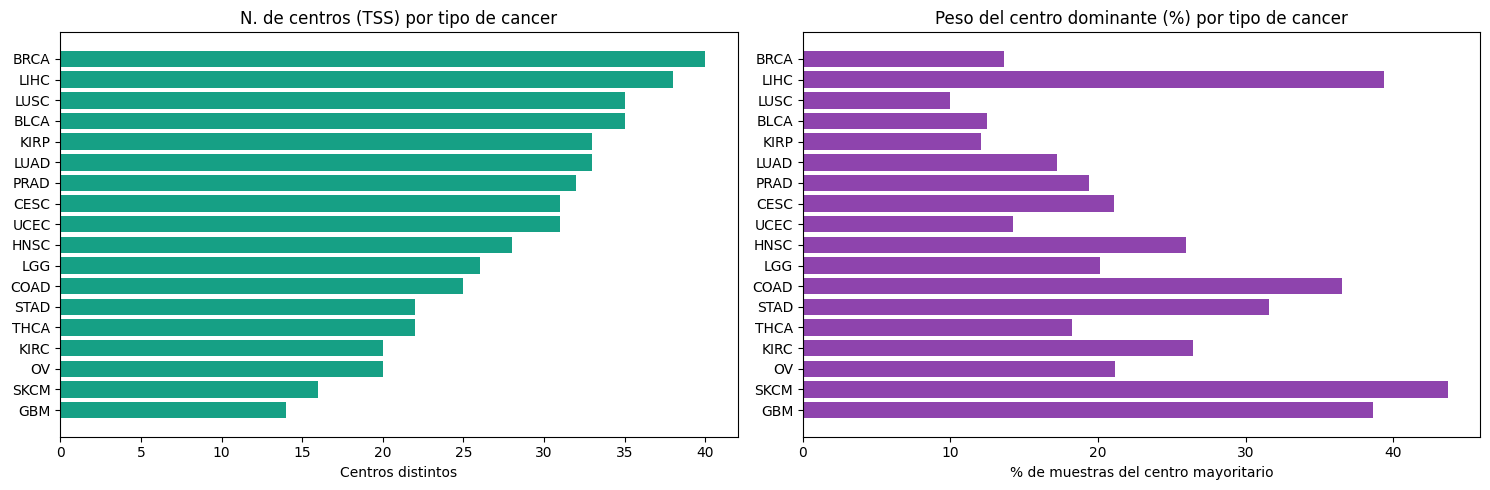

In [0]:
# === Efectos de lote: Tissue Source Site (TSS) como proxy de centro/lote ===
spark.sql("""
    CREATE OR REPLACE TEMP VIEW samples_tss AS
    SELECT *, split(case_submitter_id, '-')[1] AS tss_code
    FROM trusted_samples
""")

# Diversidad de centros dentro de cada tipo de cancer
eda_batch_centros_por_clase = spark.sql("""
    WITH por_clase_tss AS (
        SELECT cancer_type, tss_code, COUNT(DISTINCT sample_id) AS n
        FROM samples_tss GROUP BY cancer_type, tss_code
    ),
    tot AS (
        SELECT cancer_type,
               COUNT(DISTINCT sample_id) AS n_muestras,
               COUNT(DISTINCT tss_code)  AS n_centros_tss
        FROM samples_tss GROUP BY cancer_type
    ),
    dom AS (
        SELECT cancer_type, MAX(n) AS n_centro_dominante
        FROM por_clase_tss GROUP BY cancer_type
    )
    SELECT t.cancer_type, t.n_muestras, t.n_centros_tss,
           d.n_centro_dominante,
           ROUND(100 * d.n_centro_dominante / t.n_muestras, 2) AS pct_centro_dominante
    FROM tot t JOIN dom d USING (cancer_type)
    ORDER BY n_centros_tss ASC
""")
mostrar(eda_batch_centros_por_clase, 30)
save_spark_table(eda_batch_centros_por_clase, "refined_eda_batch_centros_por_clase")

# Solapamiento de TSS entre tipos de cancer (capacidad de deconfundir lote vs biologia)
eda_batch_solapamiento_tss = spark.sql("""
    WITH tss_span AS (
        SELECT tss_code,
               COUNT(DISTINCT sample_id)   AS n_muestras,
               COUNT(DISTINCT cancer_type) AS n_tipos_cancer
        FROM samples_tss GROUP BY tss_code
    )
    SELECT
        COUNT(*) AS n_tss_total,
        SUM(CASE WHEN n_tipos_cancer > 1 THEN 1 ELSE 0 END) AS n_tss_compartidos,
        SUM(CASE WHEN n_tipos_cancer = 1 THEN 1 ELSE 0 END) AS n_tss_exclusivos,
        ROUND(100 * SUM(CASE WHEN n_tipos_cancer = 1 THEN n_muestras ELSE 0 END)
              / SUM(n_muestras), 2) AS pct_muestras_en_tss_exclusivo
    FROM tss_span
""")
mostrar(eda_batch_solapamiento_tss)
save_spark_table(eda_batch_solapamiento_tss, "refined_eda_batch_solapamiento_tss")

# Visualizacion: diversidad de centros por clase y peso del centro dominante
pdf_b = eda_batch_centros_por_clase.toPandas().sort_values("n_centros_tss")
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].barh(pdf_b["cancer_type"], pdf_b["n_centros_tss"], color="#16a085")
axes[0].set_title("N. de centros (TSS) por tipo de cancer")
axes[0].set_xlabel("Centros distintos")
axes[1].barh(pdf_b["cancer_type"], pdf_b["pct_centro_dominante"], color="#8e44ad")
axes[1].set_title("Peso del centro dominante (%) por tipo de cancer")
axes[1].set_xlabel("% de muestras del centro mayoritario")
plt.tight_layout()
guardar_figura("batch_centros_tss_por_clase.png")
plt.show()


In [0]:
eda_muestras_por_paciente = spark.sql("""
    WITH muestras_paciente AS (
        SELECT patient_id, cancer_type, COUNT(DISTINCT sample_id) AS n_muestras
        FROM trusted_long
        GROUP BY patient_id, cancer_type
    )
    SELECT cancer_type,
           COUNT(*) AS n_pacientes,
           SUM(CASE WHEN n_muestras > 1 THEN 1 ELSE 0 END) AS pacientes_con_mas_de_una_muestra,
           MAX(n_muestras) AS max_muestras_por_paciente
    FROM muestras_paciente
    GROUP BY cancer_type
    ORDER BY pacientes_con_mas_de_una_muestra DESC
""")
mostrar(eda_muestras_por_paciente, 30)
save_spark_table(eda_muestras_por_paciente, "refined_eda_muestras_por_paciente")

print("Tablas refined creadas en:", REFINED_TABLES_PATH)
for p in sorted(REFINED_TABLES_PATH.iterdir()):
    print("-", p.name)


cancer_type,n_pacientes,pacientes_con_mas_de_una_muestra,max_muestras_por_paciente
COAD,458,13,2
LUAD,517,12,2
BRCA,1095,11,2
KIRC,533,4,2
UCEC,545,4,2
PRAD,497,4,2
BLCA,406,3,2
GBM,284,1,2
LGG,516,0,1
THCA,505,0,1


Tabla Delta guardada: `workspace`.`default`.`refined_eda_muestras_por_paciente`
Copia física en Volume: /Volumes/workspace/default/tcga_cancer_ml/refined/tables/refined_eda_muestras_por_paciente
Tablas refined creadas en: /Volumes/workspace/default/tcga_cancer_ml/refined/tables
- refined_eda_batch_centros_por_clase
- refined_eda_batch_solapamiento_tss
- refined_eda_calidad_datos
- refined_eda_conteo_clases
- refined_eda_desbalance_clases
- refined_eda_distribucion_expresion
- refined_eda_expresion_global
- refined_eda_genes_mas_variables
- refined_eda_muestras_por_paciente
- refined_eda_tipos_muestra
- refined_eda_top_genes_por_clase


## t-SNE: separabilidad de las 18 clases

Como cierre del EDA se proyecta el perfil de expresion (genes mas variables) a 2D con PCA + t-SNE. Si las muestras de un mismo tipo tumoral se agrupan de forma espontanea, se confirma que existe una senal transcriptomica discriminativa por clase, lo que respalda el enfoque supervisado posterior. Sirve como *sanity check* no supervisado, no como diagnostico.


  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Created wheel for openTSNE: filename=openTSNE-1.0.4-cp311-cp311-linux_aarch64.whl size=2733745 sha256=f2e5d27579611dd54acd19e78d1f82658606edb44776e57d27e898c801abc885
  Stored in directory: /home/spark-d735659a-dfd2-4705-b4b7-f6/.cache/pip/wheels/1c/0f/32/4f951613dbcb0917f04cefa2eb62af48d42abfe7e64ea48977
Successfully built openTSNE
Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.
Genes para t-SNE: 500
Matriz t-SNE: (8335, 500)


/home/spark-d735659a-dfd2-4705-b4b7-f6/.ipykernel/3334/command-5341571333548819-224197884:34: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = plt.cm.get_cmap("tab20", len(clases))


Figura guardada: /Volumes/workspace/default/tcga_cancer_ml/refined/visualizations/tsne_18_clases.png


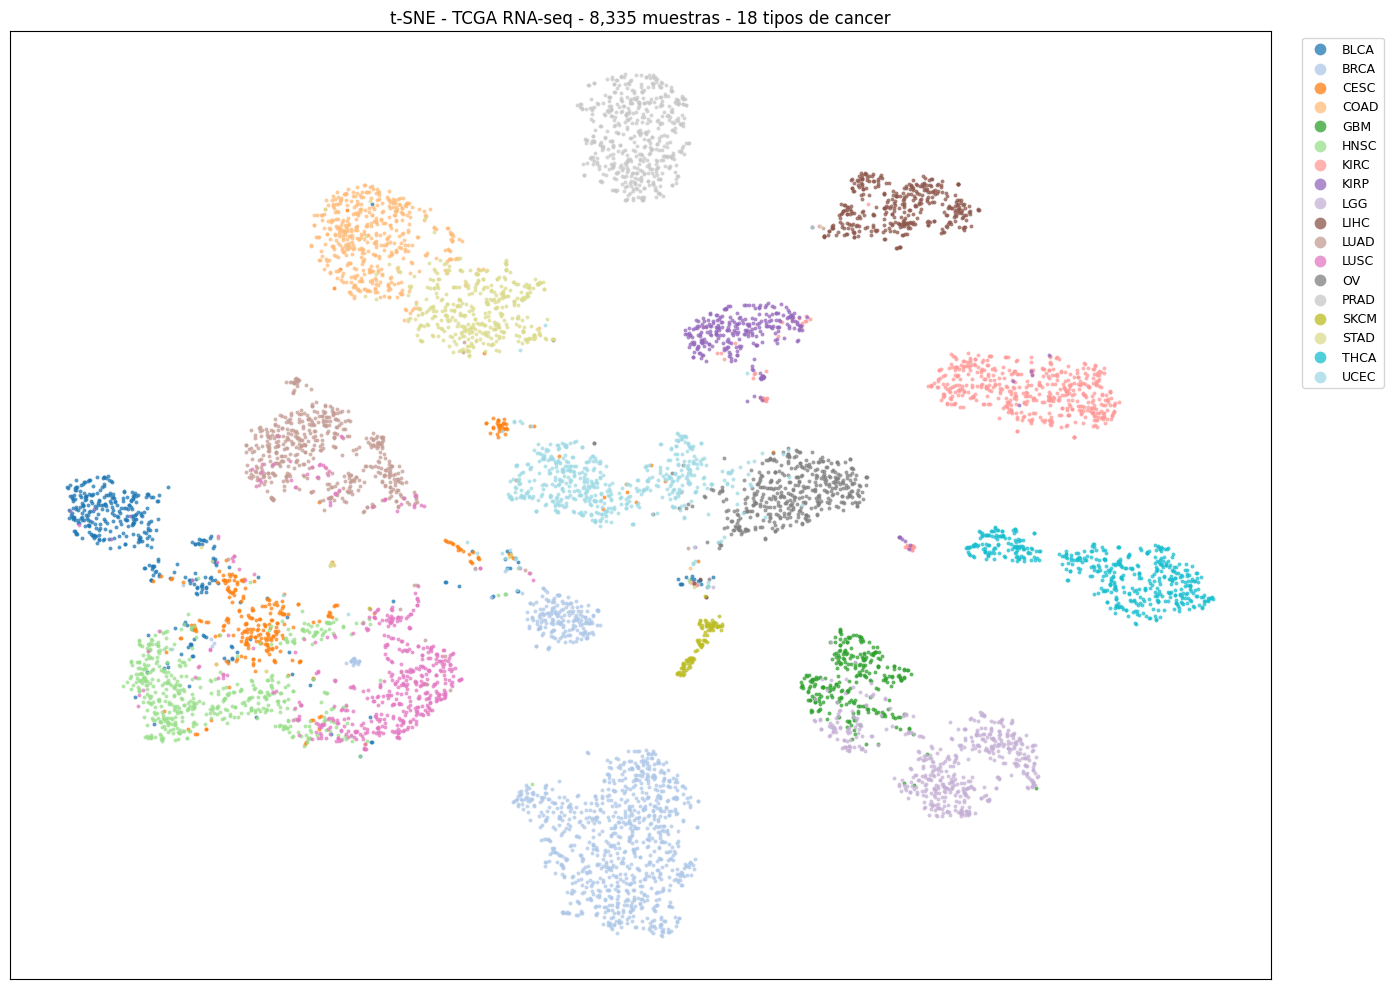

In [0]:
# === t-SNE como muestra de la distincion molecular entre clases ===
# Instalar openTSNE solo si no está disponible
try:
    import openTSNE
except ModuleNotFoundError:
    %pip install openTSNE

from sklearn.decomposition import PCA
from openTSNE import TSNE as openTSNE

N_GENES_TSNE = int(os.getenv("TCGA_N_GENES_TSNE", "500"))
genes_tsne = [
    r["gene_id_base"]
    for r in load_spark_table("refined_eda_genes_mas_variables")
        .select("gene_id_base").dropna().dropDuplicates(["gene_id_base"]).limit(N_GENES_TSNE).collect()
]
print("Genes para t-SNE:", len(genes_tsne))

df_wide_tsne = (
    spark.table("trusted_long")
    .filter(F.col("gene_id_base").isin(genes_tsne))
    .groupBy("sample_id", "cancer_type")
    .pivot("gene_id_base", genes_tsne)
    .agg(F.first("log2_tpm"))
    .fillna(0.0)
    .toPandas()
)
feat_cols = [c for c in df_wide_tsne.columns if c not in ("sample_id", "cancer_type")]
X_tsne = df_wide_tsne[feat_cols].apply(pd.to_numeric, errors="coerce").fillna(0.0).values
labels_tsne = df_wide_tsne["cancer_type"].values
print("Matriz t-SNE:", X_tsne.shape)

n_comp = min(50, X_tsne.shape[1])
X_pca = PCA(n_components=n_comp, random_state=SEED).fit_transform(X_tsne)
emb = openTSNE(n_components=2, perplexity=30, n_iter=750, random_state=SEED, n_jobs=-1).fit(X_pca)

clases = sorted(set(labels_tsne))
cmap = plt.cm.get_cmap("tab20", len(clases))
plt.figure(figsize=(14, 10))
for i, ct in enumerate(clases):
    m = labels_tsne == ct
    plt.scatter(emb[m, 0], emb[m, 1], c=[cmap(i)], label=ct, s=8, alpha=0.75, linewidths=0)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", markerscale=3, fontsize=9)
plt.title(f"t-SNE - TCGA RNA-seq - {len(labels_tsne):,} muestras - 18 tipos de cancer")
plt.xticks([]); plt.yticks([])
plt.tight_layout()
guardar_figura("tsne_18_clases.png")
plt.show()
